# 02 Average and Expected Value

このノートブックでは、平均と期待値について観察します。

前の章では、10%で当たるくじを使って、1回の結果と繰り返したときの傾向の違いを確認しました。

この章では、「10%で当たるくじを10回引いたら、平均すると何回くらい当たりそうか」を考えます。

## 1. 平均を計算する

平均は、複数の値をならして、全体としてどのくらいかを表す値です。

In [1]:
values = [2, 4, 6, 8, 10]

average = sum(values) / len(values)

print(average)

6.0


平均は、合計をデータの個数で割って求めます。

## 2. 10%で当たるくじの期待値

10%で当たるくじを10回引くとします。

1回あたり当たる確率は 0.1 です。10回引くので、平均的な当たり回数は `10 × 0.1 = 1` と考えられます。

この「平均するとどのくらいになりそうか」という考え方を、期待値といいます。

In [2]:
p = 0.1
trials_per_set = 10

expected_wins = p * trials_per_set

print(expected_wins)

1.0


期待値は1回ですが、これは「必ず1回当たる」という意味ではありません。

## 3. 実際に10回引いてみる

10%で当たるくじを10回引いて、実際に何回当たるかを確認します。

In [3]:
import random

p = 0.1
trials_per_set = 10
win_count = 0

for i in range(trials_per_set):
    if random.random() < p:
        win_count += 1

print("当たり回数:", win_count)
print("期待値:", p * trials_per_set)

当たり回数: 1
期待値: 1.0


このセルを何度か実行してみてください。

期待値は1回ですが、実際の当たり回数は0回、1回、2回以上など、変わることがあります。

## 4. 10回引く実験を1000セット繰り返す

1セットだけでは結果がぶれます。

そこで、「10回引く」という実験を1000セット繰り返し、各セットの当たり回数を記録します。

In [4]:
import random

p = 0.1
trials_per_set = 10
set_count = 1000

results = []

for set_number in range(set_count):
    win_count = 0

    for i in range(trials_per_set):
        if random.random() < p:
            win_count += 1

    results.append(win_count)

print(results[:20])

[0, 0, 3, 1, 0, 1, 0, 0, 2, 2, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1]


最初の20セット分だけ表示しています。

同じ10回の試行でも、当たり回数はセットごとに違います。

## 5. 1000セットの平均を求める

1000セット分の当たり回数の平均を求めます。

In [5]:
average_wins = sum(results) / len(results)

print("1000セットの平均当たり回数:", average_wins)
print("理論上の期待値:", p * trials_per_set)

1000セットの平均当たり回数: 0.983
理論上の期待値: 1.0


1000セットの平均当たり回数は、理論上の期待値である 1 に近づきやすくなります。

ただし、毎回ぴったり1になるとは限りません。

## 6. 結果をグラフで見る

各セットで、当たり回数が何回だったかを数えて、グラフにします。

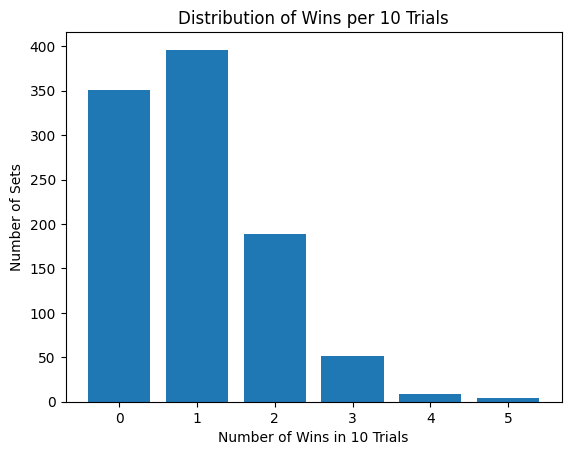

In [6]:
import matplotlib.pyplot as plt

counts = {}

for result in results:
    if result not in counts:
        counts[result] = 0
    counts[result] += 1

x = sorted(counts.keys())
y = [counts[key] for key in x]

plt.bar(x, y)
plt.xlabel("Number of Wins in 10 Trials")
plt.ylabel("Number of Sets")
plt.title("Distribution of Wins per 10 Trials")
plt.show()

このグラフを見ると、10回引いたときに何回当たることが多いのかを確認できます。

期待値は1回ですが、実際には0回や2回になることもあります。

## 7. 平均が同じでも中身は違う

平均は便利ですが、平均だけでデータの特徴をすべて説明できるわけではありません。

In [7]:
a = [4, 5, 6]
b = [0, 5, 10]

average_a = sum(a) / len(a)
average_b = sum(b) / len(b)

print("Aの平均:", average_a)
print("Bの平均:", average_b)

Aの平均: 5.0
Bの平均: 5.0


AもBも平均は5です。

しかし、Aは5の近くに集まっています。Bは0から10まで大きくばらついています。

平均が同じでも、データの状態が同じとは限りません。

## 8. 平均が同じデータをグラフで見る

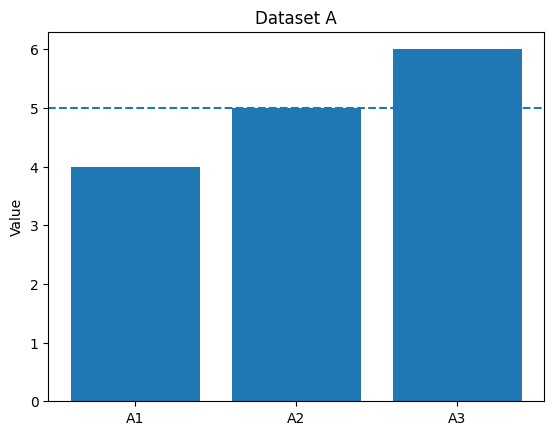

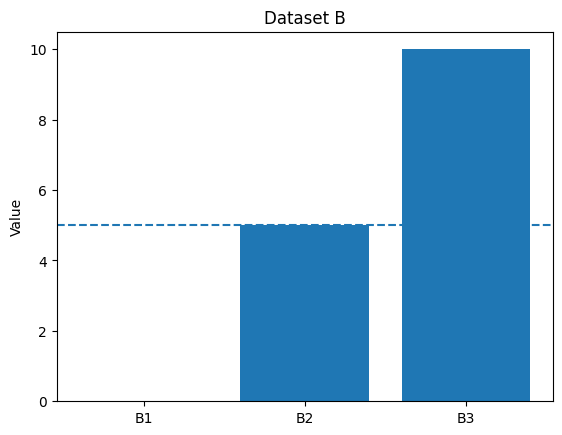

In [8]:
import matplotlib.pyplot as plt

plt.bar(["A1", "A2", "A3"], a)
plt.axhline(average_a, linestyle="--")
plt.title("Dataset A")
plt.ylabel("Value")
plt.show()

plt.bar(["B1", "B2", "B3"], b)
plt.axhline(average_b, linestyle="--")
plt.title("Dataset B")
plt.ylabel("Value")
plt.show()

どちらも平均は同じですが、値の散らばり方は違います。

次の章では、この「ばらつき」を表す分散と標準偏差について学びます。

## 9. ビジネスとのつながり

平均や期待値は、ビジネスの見込みを考えるときに使えます。

- クリック率が10%なら、100回表示で平均10クリックくらい期待できる
- 成約率が5%なら、200件営業で平均10件くらい期待できる
- 平均購入金額が3000円なら、100人購入で平均30万円くらいの売上が期待できる

ただし、これはあくまで平均的な見込みです。実際の結果は、平均より多いことも少ないこともあります。

## 10. このノートブックで確認したこと

- 平均は、複数の値をならした代表値である
- 期待値は、確率的な出来事を繰り返したときの平均的な見込みである
- 期待値は、必ずそうなる結果ではない
- 10%で当たるくじを10回引くと、当たり回数の期待値は1回である
- 実際の結果にはばらつきがある
- 平均が同じでも、データの散らばり方が同じとは限らない

次の章では、分散と標準偏差について学びます。